In [1]:
# ============================================================
# 02_eda.ipynb — Phase 2: Exploratory Data Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
os.makedirs('../reports/eda_figures', exist_ok=True)

df = pd.read_csv('../data/processed/cleaned_data.csv')
print(df.shape)
df.head()

(69973, 52)


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary,diag_1_group,diag_2_group,diag_3_group,age_ordinal
0,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,...,No,No,No,No,NO,0,Diabetes,Missing,Missing,0
1,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,...,No,No,Ch,Yes,>30,0,Other,Diabetes,Other,1
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,...,No,No,No,Yes,NO,0,Other,Diabetes,Other,2
3,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,...,No,No,Ch,Yes,NO,0,Other,Diabetes,Circulatory,3
4,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,...,No,No,Ch,Yes,NO,0,Neoplasm,Neoplasm,Diabetes,4


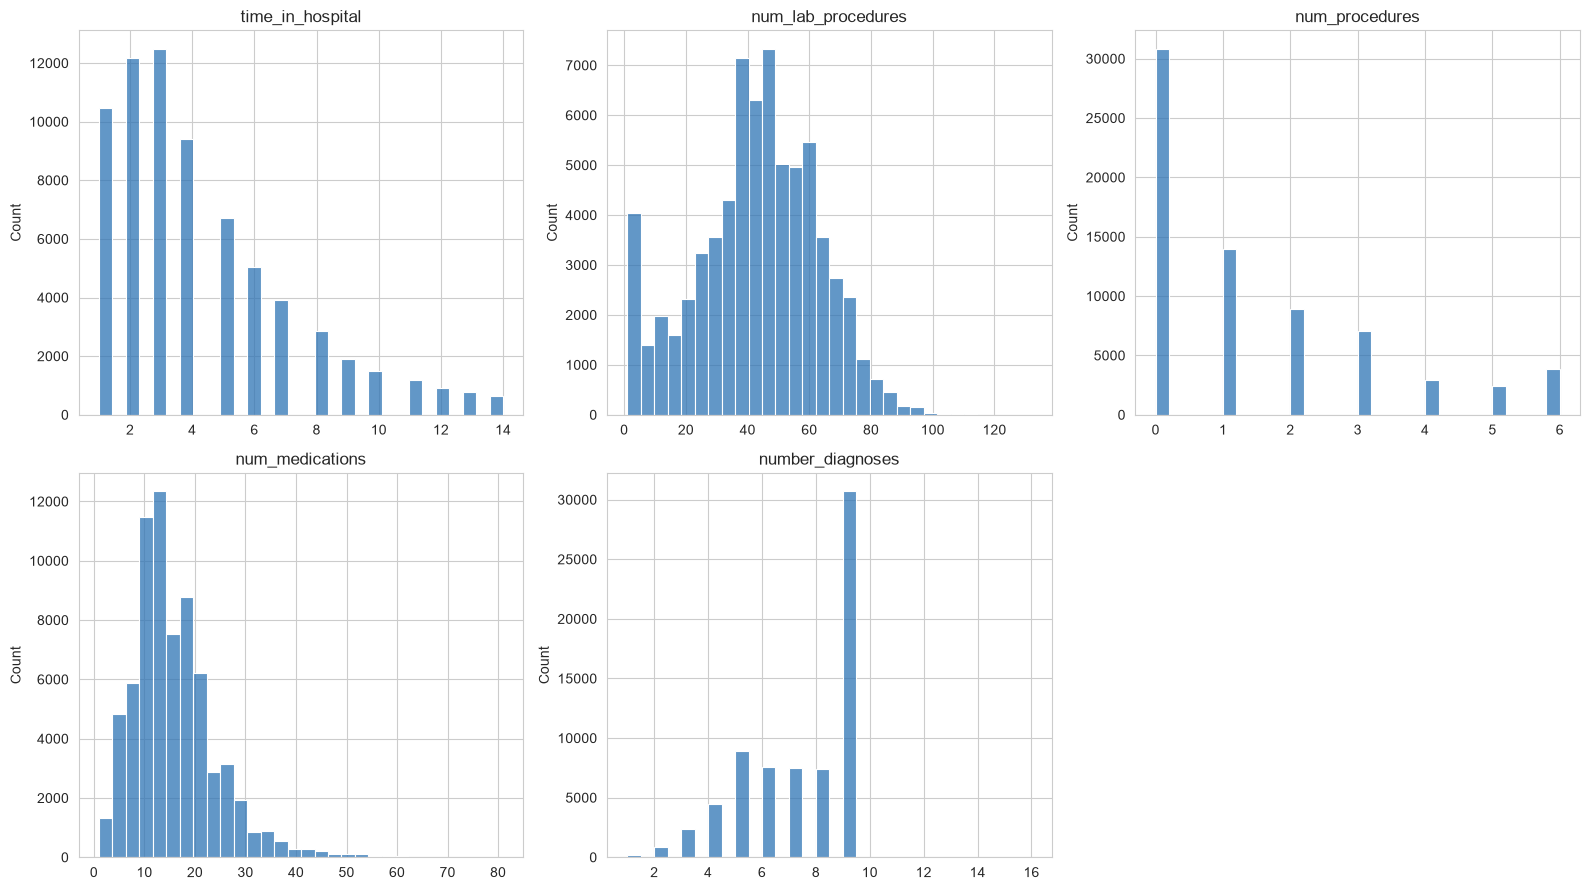

                      count       mean        std  min   25%   50%   75%  \
time_in_hospital    69973.0   4.273220   2.933924  1.0   2.0   3.0   6.0   
num_lab_procedures  69973.0  42.876038  19.894530  1.0  31.0  44.0  57.0   
num_procedures      69973.0   1.425536   1.757131  0.0   0.0   1.0   2.0   
num_medications     69973.0  15.665257   8.287246  1.0  10.0  14.0  20.0   
number_diagnoses    69973.0   7.223743   2.001354  1.0   6.0   8.0   9.0   

                      max  
time_in_hospital     14.0  
num_lab_procedures  132.0  
num_procedures        6.0  
num_medications      81.0  
number_diagnoses     16.0  


In [2]:
# --- Numeric feature distributions ---
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                 'num_medications', 'number_diagnoses']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=30, ax=ax, color='#2E74B5')
    ax.set_title(col)
    ax.set_xlabel('')
fig.delaxes(axes.flat[-1])  # remove unused 6th subplot
plt.tight_layout()
plt.savefig('../reports/eda_figures/numeric_distributions.png', dpi=150)
plt.show()

# --- Summary stats table ---
print(df[numeric_cols].describe().T)

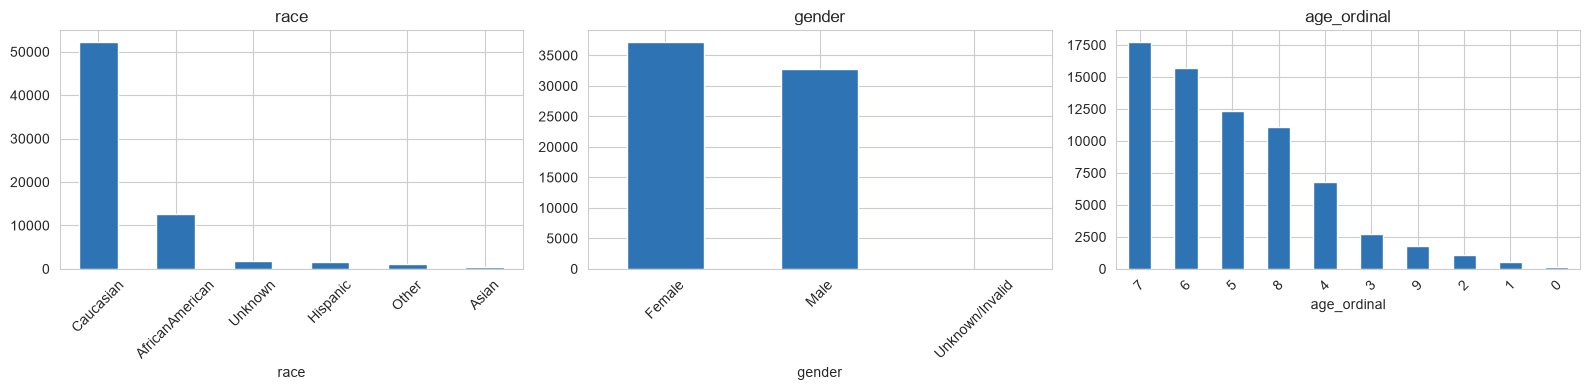


--- race ---
race
Caucasian          52292
AfricanAmerican    12625
Unknown             1918
Hispanic            1500
Other               1150
Asian                488
Name: count, dtype: int64

--- gender ---
gender
Female             37229
Male               32741
Unknown/Invalid        3
Name: count, dtype: int64

--- age_ordinal ---
age_ordinal
7    17750
6    15684
5    12349
8    11102
4     6828
3     2692
9     1760
2     1121
1      534
0      153
Name: count, dtype: int64


In [3]:
# --- Categorical frequency counts ---
categorical_cols = ['race', 'gender', 'age_ordinal']  # adjust names to match your Step 1.8 output

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(16, 4))
for ax, col in zip(axes, categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='#2E74B5')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/eda_figures/categorical_frequencies.png', dpi=150)
plt.show()

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

age
[80-90)     0.107638
[70-80)     0.102366
[90-100)    0.095455
[60-70)     0.090028
[40-50)     0.074107
[20-30)     0.074041
[50-60)     0.071180
[30-40)     0.069837
[10-20)     0.048689
[0-10)      0.019608
Name: readmitted_binary, dtype: float64


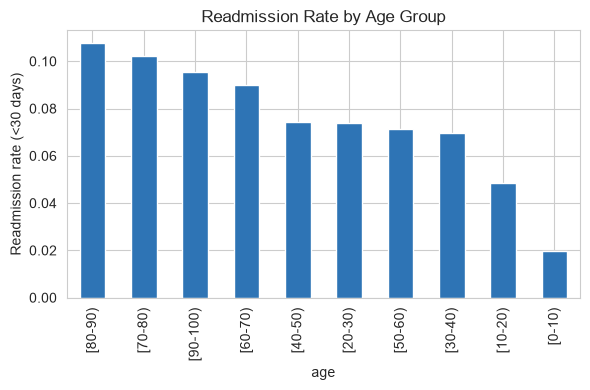

In [4]:
target_col = 'readmitted_binary'  # adjust to your actual target column name from Step 1.6

def readmit_rate_by(col, df=df, target=target_col):
    rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    return rate

# --- Readmission rate by age group ---
age_rate = readmit_rate_by('age')
print(age_rate)

fig, ax = plt.subplots(figsize=(6, 4))
age_rate.plot(kind='bar', ax=ax, color='#2E74B5')
ax.set_ylabel('Readmission rate (<30 days)')
ax.set_title('Readmission Rate by Age Group')
plt.tight_layout()
plt.savefig('../reports/eda_figures/readmit_by_age.png', dpi=150)
plt.show()

admission_type_id
4    0.111111
6    0.099646
1    0.091693
2    0.089673
5    0.085548
3    0.082771
8    0.072165
7    0.000000
Name: readmitted_binary, dtype: float64


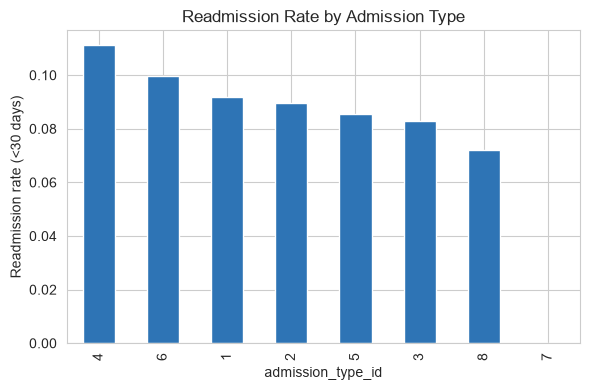

In [5]:
# --- Readmission rate by admission type ---
adm_rate = readmit_rate_by('admission_type_id')
print(adm_rate)

fig, ax = plt.subplots(figsize=(6, 4))
adm_rate.plot(kind='bar', ax=ax, color='#2E74B5')
ax.set_ylabel('Readmission rate (<30 days)')
ax.set_title('Readmission Rate by Admission Type')
plt.tight_layout()
plt.savefig('../reports/eda_figures/readmit_by_admission_type.png', dpi=150)
plt.show()

number_inpatient
12    1.000000
10    0.800000
11    0.500000
7     0.473684
9     0.428571
6     0.400000
5     0.284314
3     0.237581
4     0.236842
8     0.230769
2     0.185210
1     0.128926
0     0.081173
Name: readmitted_binary, dtype: float64


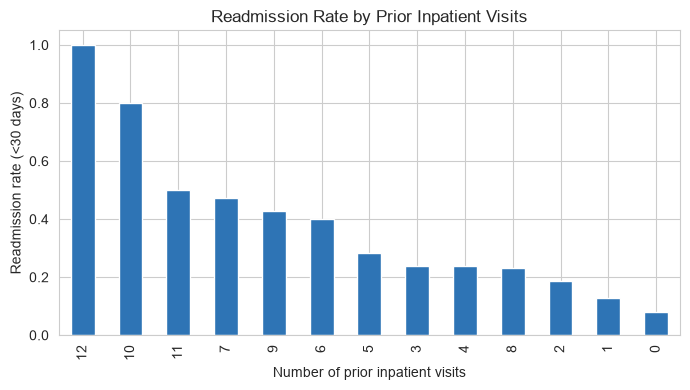

In [6]:
# --- Readmission rate by prior inpatient visits (strongest expected signal) ---
inpatient_rate = readmit_rate_by('number_inpatient')
print(inpatient_rate)

fig, ax = plt.subplots(figsize=(7, 4))
inpatient_rate.plot(kind='bar', ax=ax, color='#2E74B5')
ax.set_ylabel('Readmission rate (<30 days)')
ax.set_xlabel('Number of prior inpatient visits')
ax.set_title('Readmission Rate by Prior Inpatient Visits')
plt.tight_layout()
plt.savefig('../reports/eda_figures/readmit_by_prior_inpatient.png', dpi=150)
plt.show()

diag_1_group
Missing            0.200000
Injury             0.107797
Circulatory        0.096661
Diabetes           0.091162
Neoplasm           0.090623
Genitourinary      0.089826
Other              0.089672
Musculoskeletal    0.083907
Digestive          0.080160
Respiratory        0.072844
Name: readmitted_binary, dtype: float64


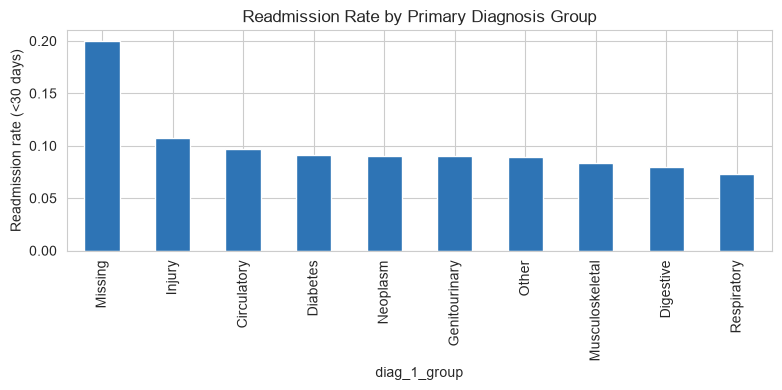

In [7]:
# --- Readmission rate by primary diagnosis group ---
diag_rate = readmit_rate_by('diag_1_group')  # adjust to your Step 1.7 column name
print(diag_rate)

fig, ax = plt.subplots(figsize=(8, 4))
diag_rate.plot(kind='bar', ax=ax, color='#2E74B5')
ax.set_ylabel('Readmission rate (<30 days)')
ax.set_title('Readmission Rate by Primary Diagnosis Group')
plt.tight_layout()
plt.savefig('../reports/eda_figures/readmit_by_diagnosis.png', dpi=150)
plt.show()

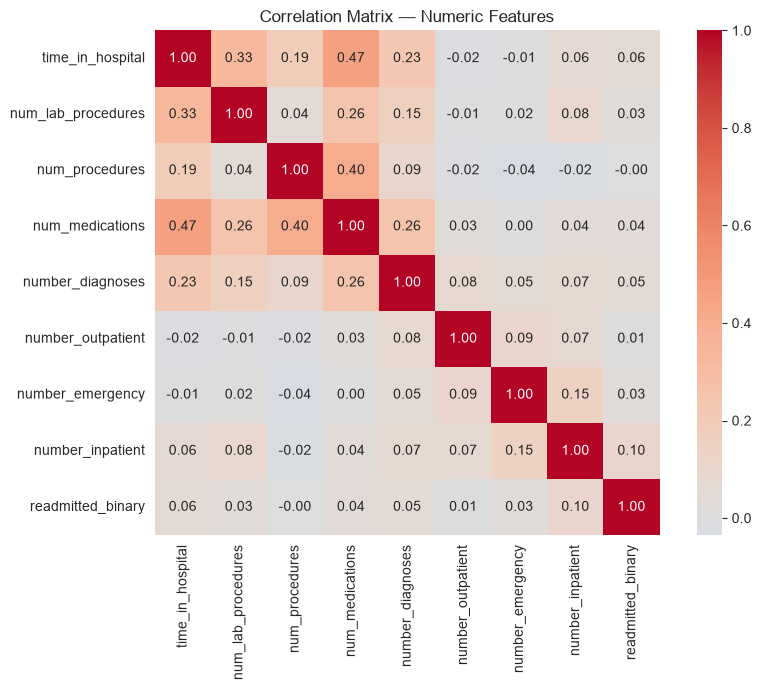

Empty DataFrame
Columns: [feature_1, feature_2, correlation]
Index: []


In [8]:
corr_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
             'num_medications', 'number_diagnoses', 'number_outpatient',
             'number_emergency', 'number_inpatient', target_col]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('../reports/eda_figures/correlation_heatmap.png', dpi=150)
plt.show()

# Flag any pair with |correlation| > 0.7 (redundancy candidates)
high_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) \
                        .stack().reset_index()
high_corr.columns = ['feature_1', 'feature_2', 'correlation']
print(high_corr[high_corr['correlation'].abs() > 0.7])

readmitted_binary
0    63696
1     6277
Name: count, dtype: int64
readmitted_binary
0    91.03
1     8.97
Name: proportion, dtype: float64


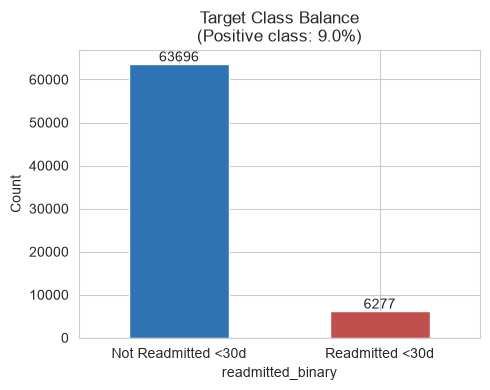


Imbalance ratio: 10.15 : 1
This confirms why Recall / PR-AUC are prioritized over accuracy in Phase 4 evaluation.


In [9]:
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', ax=ax, color=['#2E74B5', '#C0504D'])
ax.set_xticklabels(['Not Readmitted <30d', 'Readmitted <30d'], rotation=0)
ax.set_ylabel('Count')
ax.set_title(f'Target Class Balance\n(Positive class: {class_pct[1]:.1f}%)')
for i, v in enumerate(class_counts):
    ax.text(i, v + 500, str(v), ha='center')
plt.tight_layout()
plt.savefig('../reports/eda_figures/class_balance.png', dpi=150)
plt.show()

print(f"\nImbalance ratio: {class_counts[0] / class_counts[1]:.2f} : 1")
print("This confirms why Recall / PR-AUC are prioritized over accuracy in Phase 4 evaluation.")

In [10]:
print("=== EDA SUMMARY ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Positive class rate: {class_pct[1]:.2f}%")
print(f"Highest readmission-rate age group: {age_rate.idxmax()} ({age_rate.max():.3f})")
print(f"Highest readmission-rate diagnosis group: {diag_rate.idxmax()} ({diag_rate.max():.3f})")
print("Figures saved to: reports/eda_figures/")

=== EDA SUMMARY ===
Rows: 69973, Columns: 52
Positive class rate: 8.97%
Highest readmission-rate age group: [80-90) (0.108)
Highest readmission-rate diagnosis group: Missing (0.200)
Figures saved to: reports/eda_figures/


In [11]:
import pandas as pd

df = pd.read_csv('../data/processed/cleaned_data.csv')
print(df.shape)

print(df.groupby('diag_1_group').size())
print(df.groupby('diag_1_group')['readmitted_binary'].agg(['mean', 'count']))

(69973, 52)
diag_1_group
Circulatory        21384
Diabetes            5748
Digestive           6487
Genitourinary       3440
Injury              4694
Missing               10
Musculoskeletal     4064
Neoplasm            2538
Other              12122
Respiratory         9486
dtype: int64
                     mean  count
diag_1_group                    
Circulatory      0.096661  21384
Diabetes         0.091162   5748
Digestive        0.080160   6487
Genitourinary    0.089826   3440
Injury           0.107797   4694
Missing          0.200000     10
Musculoskeletal  0.083907   4064
Neoplasm         0.090623   2538
Other            0.089672  12122
Respiratory      0.072844   9486


In [12]:
print(df.groupby('diag_1_group')['readmitted_binary'].mean().sort_values(ascending=False))

diag_1_group
Missing            0.200000
Injury             0.107797
Circulatory        0.096661
Diabetes           0.091162
Neoplasm           0.090623
Genitourinary      0.089826
Other              0.089672
Musculoskeletal    0.083907
Digestive          0.080160
Respiratory        0.072844
Name: readmitted_binary, dtype: float64
